In [ ]:
!pip install imagecodecs
!pip install patchify
!pip install rasterio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 39.5/39.5 MB 49.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.5/21.5 MB 73.2 MB/s eta 0:00:00


### Notebook created to make forest cover predictions on copernicus satellite images

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

import PIL
from PIL import Image

import concurrent.futures

from tensorflow.keras.utils import Sequence

import imagecodecs
from glob import glob
from patchify import patchify

import os
import rasterio
from rasterio.transform import from_origin

from patchify import patchify

import tensorflow.keras.layers as L
from tensorflow.keras.callbacks import ModelCheckpoint, CSVLogger, ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.models import Model, load_model

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Load Images Paths

In [ ]:
### function to return image paths ###
def return_image_paths(dir):
    image_paths = []
    dates = ['20210616', '20210929']

    for filename in os.listdir(dir):
        for date in dates:
            if date in filename:
                image_path = os.path.join(dir, filename)
                image_paths.append(image_path)
                break
    return image_paths


### 06/16/2021 - 09/292021 ###
# load first and last image from each location

mendocino_first_dir = '/content/drive/MyDrive/copernicus_data/mendocino_first_tci_image'
mendocino_last_dir = '/content/drive/MyDrive/copernicus_data/mendocino_last_tci_image'


shastatrinity_first_dir = '/content/drive/MyDrive/copernicus_data/shastatrinity_first_tci_image'
shastatrinity_last_dir = '/content/drive/MyDrive/copernicus_data/shastatrinity_last_tci_image'

sixrivers_first_dir = '/content/drive/MyDrive/copernicus_data/sixrivers_first_tci_image'
sixrivers_last_dir = '/content/drive/MyDrive/copernicus_data/sixrivers_last_tci_image'



mendocino_paths = sorted( (return_image_paths(mendocino_first_dir)+return_image_paths(mendocino_last_dir)) )
shastatrinity_paths = sorted( (return_image_paths(shastatrinity_first_dir)+return_image_paths(shastatrinity_last_dir)) )
sixrivers_paths = sorted( (return_image_paths(sixrivers_first_dir)+return_image_paths(sixrivers_last_dir)) )

In [ ]:
Image.MAX_IMAGE_PIXELS = None

def load_image(path):
    img = Image.open(path)
    img_array = np.array(img)
    img_arr = cv2.resize(img_array, (6800,6800), interpolation = cv2.INTER_AREA)
    return (path.split('cropped_')[1][:15], img_arr)

In [ ]:
### Load Images
### resize imges to (6800,6800) ###


###### Tile TDL ######
"""shape: (6210, 6821, 3) """
TDL_20210721 = '/content/drive/MyDrive/ARC_GIS_testing_data/last_tci_image/cropped_T10TDL_20210721T185921_TCI_10m.jp2'
TDL_20210929 = '/content/drive/MyDrive/ARC_GIS_testing_data/last_tci_image/cropped_T10TDL_20210929T190201_TCI_10m.jp2'

###### Tile TDM ######
"""shape: (6916, 6821, 3) """
TDM_20210711 = '/content/drive/MyDrive/ARC_GIS_testing_data/last_tci_image/cropped_T10TDM_20210711T185921_TCI_10m.jp2'
TDM_20210929 = '/content/drive/MyDrive/ARC_GIS_testing_data/last_tci_image/cropped_T10TDM_20210929T190201_TCI_10m.jp2'

###### Tile TEL ######
"""shape: (6210, 3633, 3) """
TEL_20210711 = '/content/drive/MyDrive/ARC_GIS_testing_data/last_tci_image/cropped_T10TEL_20210711T185921_TCI_10m.jp2'
TEL_20210929 = '/content/drive/MyDrive/ARC_GIS_testing_data/last_tci_image/cropped_T10TEL_20210929T190201_TCI_10m.jp2'

###### Tile TEM ######
"""shape: (6916, 3633, 3) """

TEM_20210711 = '/content/drive/MyDrive/ARC_GIS_testing_data/last_tci_image/cropped_T10TEM_20210711T185921_TCI_10m.jp2'
TEM_20210929 = '/content/drive/MyDrive/ARC_GIS_testing_data/last_tci_image/cropped_T10TEM_20210929T190201_TCI_10m.jp2'


image_path_list = [TDL_20210721,TDL_20210929,
                   TDM_20210711,TDM_20210929,
                   TEL_20210711,TEL_20210929,
                   TEM_20210711,TEM_20210929]
image_names = ['TDL_20210721','TDL_20210929',
               'TDM_20210711','TDM_20210929',
               'TEL_20210711','TEL_20210929',
               'TEM_20210711','TEM_20210929']
img_dict = {}

for i in range(len(image_path_list)):
  img_dict[image_names[i]] = load_image(image_path_list[i])

## Load Model

In [ ]:
## loss functions
smooth = 1e-15
def dice_coef(y_true, y_pred):
    y_true = tf.keras.layers.Flatten()(y_true)
    y_pred = tf.keras.layers.Flatten()(y_pred)
    intersection = tf.reduce_sum(y_true * y_pred)
    return (2. * intersection + smooth) / (tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) + smooth)

def dice_loss(y_true, y_pred):
    return 1.0 - dice_coef(y_true, y_pred)

def bce_dice_loss(y_true, y_pred):
    return tf.keras.losses.binary_crossentropy(y_true, y_pred) + dice_loss(y_true, y_pred)


### Load Model ###
"""Different models have different custom objects - check each model"""
model_path = os.path.join("/content/drive/MyDrive/split_images/model_info,", "dual_input_model80.keras")
model = load_model(model_path, custom_objects={'dice_loss':dice_loss,
                                               'dice_coef':dice_coef,
                                               'bce_dice_loss':bce_dice_loss})

#### generate predictions

In [ ]:
#### previous hyperparameters ####
img_size = 400
num_channels = 3
NUM_LAYERS = 12
HIDDEN_DIM = 400

NUM_HEADS = 6
DROPOUT = 0.1
PATCH_SIZE = 16
NUM_PATCHES = (img_size*img_size) // (PATCH_SIZE*PATCH_SIZE)
TOTAL_PATCHES_SHAPE = (NUM_PATCHES, PATCH_SIZE*PATCH_SIZE*num_channels)


#### generate patches from images ####
def generate_patches(img_arr):
  """ Function to generate (400,400,3) patches from larger images """

  patches = patchify(img_arr,(400,400,3),step=400)
  num_patches_y, num_patches_x, _, patch_height, patch_width, num_channels = patches.shape
  reshaped_patches = patches.reshape(num_patches_y * num_patches_x, patch_height, patch_width, num_channels)

  return reshaped_patches

#### functions for predictions ####
def predictions(image):

    """ Function to generate 16 by 16 patches form (400,400) images and make predictions """
    # read images
    image = cv2.resize(image, (400, 400))
    x = image / 255.0

    patch_shape = (PATCH_SIZE, PATCH_SIZE, num_channels)
    patches = patchify(x, patch_shape, PATCH_SIZE)
    patches = np.reshape(patches, TOTAL_PATCHES_SHAPE)
    patches = patches.astype(np.float32)
    patches = np.expand_dims(patches, axis=0)

    # run prediction
    pred = model.predict(patches, verbose=0)[0]
    return pred



#### reconstruct images from patches ####
def reconstruct_image_from_patches(patches, patch_size=(400, 400), image_shape=(6800, 6800)):

    """reconstructs the (400,400) predictions back into the original images"""
    num_patches = patches.shape[0]
    patch_height, patch_width = patch_size

    num_patches_y = num_patches_x = int(np.sqrt(num_patches))
    reconstructed_image = np.zeros(image_shape, dtype=np.float32)

    for i in range(num_patches_y):
        for j in range(num_patches_x):
            start_x, start_y = j * patch_width, i * patch_height
            end_x, end_y = start_x + patch_width, start_y + patch_height
            reconstructed_image[start_y:end_y, start_x:end_x] = patches[i * num_patches_x + j]

    return reconstructed_image

#### creat patches, predict, and reconstruct ####
def create_patches_reconstruct_image(image_array):

    """function to package everything together """
    reshaped_patches = generate_patches(image_array)

    result = []
    for image in reshaped_patches:
      result.append(predictions(image))

    #### reconstruct image from patches ####
    patches = np.squeeze(np.array(result))
    patch_size = (400, 400)
    image_shape = (6800, 6800)

    reconstructed_image = reconstruct_image_from_patches(patches, patch_size=patch_size, image_shape=image_shape)

    return reconstructed_image.round()




## load images and image names - create deforestation mask

In [ ]:
### Function to create deforestation mask ###
""" finds areas in first image that were values of 1 but turned to values of 0 in second image """
def calculate_deforestation_mask(mask_earlier, mask_later):
    deforestation_mask = (mask_earlier == 1) & (mask_later == 0)
    return deforestation_mask.astype(np.uint8)


##### SET DEFORESTATION LOCATION #####
""" can iterate through all at once, but currently visually inspecting images """
# location = 'mendocino'
list_of_paths = mendocino_paths
# list_of_paths = shastatrinity_paths
# list_of_paths = sixrivers_paths

# load images in parallel
with concurrent.futures.ThreadPoolExecutor() as executor:
    images = list(executor.map(load_image, list_of_paths))

## print list of filenames  - to double check
print(list(enumerate([image[0] for image in images])))

[(0, 'T10SDJ_20210616'), (1, 'T10SEJ_20210616'), (2, 'T10TDK_20210616'), (3, 'T10TEK_20210616'), (4, 'T10SDJ_20210929'), (5, 'T10SEJ_20210929'), (6, 'T10TDK_20210929'), (7, 'T10TEK_20210929')]


In [ ]:
#### save predictions to a list ####
"""
Looking at 1 prediction at a time
"""
### set indexes for making predictions and viewing masks
location = 'mendocino'
first_index = 3
second_index = 7


## First Image ##
first_image_array = images[first_index][1]
first_mask = create_patches_reconstruct_image(first_image_array)



## Second Image ##
second_image_array = images[second_index][1]
second_mask = create_patches_reconstruct_image(second_image_array)


##### CALCULATE DIFFERENCE MASK #####
difference_mask = calculate_deforestation_mask(first_mask,second_mask).astype(int)
path = f"/content/drive/MyDrive/copernicus_data/new_deforestation_masks/{location}_{images[first_index][0]}_{images[second_index][0]}_deforestation.jp2"


### SAVE THE MASK ###
diff_mask = (difference_mask * 255).astype(np.uint8)
img = Image.fromarray(diff_mask)
img.save(path)
# save_image_mask_as_jp2(difference_mask, path)

## Visualize

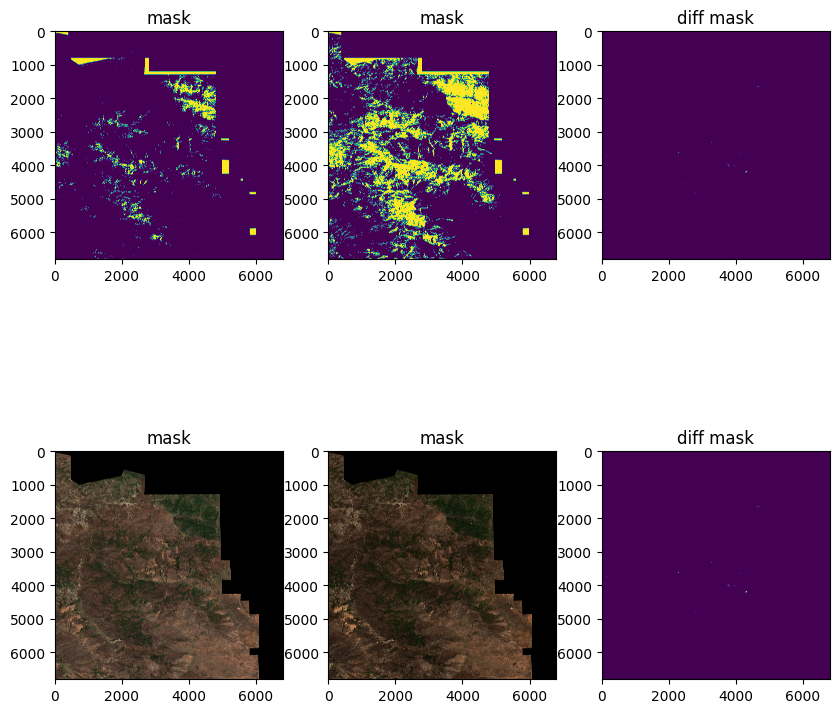

In [ ]:
#### display reconstructed image ####
## plot original and mask cover ##
fig,axs = plt.subplots(2,3,figsize=(10,10))

axs[0,0].imshow(first_mask)
axs[0,1].imshow(second_mask)
axs[0,2].imshow(diff_mask)

axs[0,0].set_title("mask")
axs[0,1].set_title("mask")
axs[0,2].set_title("diff mask")

axs[1,0].imshow(images[first_index][1])
axs[1,1].imshow(images[second_index][1])
axs[1,2].imshow(diff_mask)


axs[1,0].set_title("mask")
axs[1,1].set_title("mask")
axs[1,2].set_title("diff mask")

plt.show()
